# The Forward-Forward Algorithm: Some Preliminary Investigations
**Author:** Geoffrey Hinton (Google Brain)

# https://arxiv.org/pdf/2212.13345

## Abstract
This paper introduces the Forward-Forward (FF) algorithm, a learning procedure for neural networks that replaces the forward and backward passes of backpropagation with two forward passes operating on positive (real) and negative (self-generated or corrupted) data. Each layer has a local objective — maximizing a "goodness" measure (e.g., sum of squared activities) for positive data and minimizing it for negative data. The paper demonstrates FF's viability on small-scale problems (MNIST, CIFAR-10), showing performance comparable to, though slightly worse than, backpropagation, while offering greater biological plausibility and compatibility with unknown or non-differentiable forward computations.

## Problems
- **Biological implausibility of backpropagation:** No convincing evidence that the cortex propagates error derivatives or stores activities for a backward pass; top-down cortical connections do not mirror bottom-up ones as backpropagation would require.
- **Sequential learning constraints:** Backpropagation through time requires halting the pipeline to compute gradients, which is inconsistent with real-time sensory processing in the brain.
- **Dependence on a known forward model:** Backpropagation requires exact knowledge of forward-pass computations; inserting a non-differentiable "black box" breaks gradient computation.
- **Reinforcement learning as an alternative** scales poorly due to high variance in weight perturbation methods for large parameter counts.

## Proposed Solutions
The **Forward-Forward algorithm** replaces backpropagation's forward/backward pass pair with two structurally identical forward passes:
- **Positive pass:** real data, adjusting weights to increase per-layer goodness.
- **Negative pass:** negative data (network-generated or hand-crafted), adjusting weights to decrease per-layer goodness.

Goodness for a layer is defined via logistic classification of squared activations against a threshold:

$$p(\text{positive}) = \sigma\left(\sum_j y_j^2 - \theta\right)$$

Layer normalization strips the magnitude (goodness) signal from activations before passing them to the next layer, forcing subsequent layers to learn new, non-redundant features from relative activity patterns.

## Purpose
To establish whether a biologically plausible, gradient-free, layer-local learning procedure can perform competitively with backpropagation on small problems, while enabling (1) learning through non-differentiable "black box" components, (2) online learning without storing activities or halting for gradient propagation, and (3) implementation on low-power analog hardware.

## Methodology
| Component | Description |
|---|---|
| **Datasets** | MNIST (permutation-invariant and spatially-structured), CIFAR-10 |
| **Negative data generation** | Hand-crafted masks blending two digit images (long-range vs. short-range correlation manipulation); incorrect-label embedding in supervised setting; network self-generated negatives via recurrent forward passes |
| **Architectures** | Fully connected ReLU networks (4 hidden layers × 2000 units); locally-connected (non-weight-shared) networks; recurrent multi-layer networks for video-like static image processing |
| **Goodness function** | Sum of squared ReLU activities (with a variant using negative sum of squares) |
| **Regularization** | Peer normalization (regressing average unit activity toward a running-mean target) |
| **Classification at test time** | Either single forward pass with neutral label, or per-label forward passes accumulating goodness across layers, selecting the highest-goodness label |
| **CIFAR-10 setup** | Locally-connected topographic maps (32×32×3 units per layer, 11×11 receptive fields), compared against a backpropagation baseline with equivalent connectivity |

## Results
| Task/Setup | Test Error |
|---|---|
| Backprop baseline, permutation-invariant MNIST | ~1.4% (standard), ~1.1% (regularized) |
| FF, unsupervised, fully connected (4 layers) | 1.37% |
| FF, unsupervised, local receptive fields + peer norm | 1.16% |
| FF, supervised (label-in-input), 60 epochs | 1.36% |
| FF, supervised, jittered data augmentation, 500 epochs | 0.64% (comparable to convolutional backprop nets) |
| FF, recurrent/video-style processing | 1.31% |
| CIFAR-10, FF vs. backprop (2–3 hidden layers, local receptive fields) | FF: 41–46% test error; BP: 37–39% test error |

Additional findings: FF's first hidden layer, when trained with label information embedded in the input, develops interpretable receptive fields resembling class-discriminative features. Attempts to fully separate positive and negative learning phases in time (mimicking wake/sleep cycles) succeeded only under narrow conditions (very low learning rate, high momentum), leaving full temporal separation an open problem. FF was also related theoretically to Boltzmann Machines, GANs, and SimCLR-style contrastive methods, with FF interpreted as a special case avoiding backpropagation in both discriminative and generative roles.

## Conclusions
FF is a viable, though not superior, alternative to backpropagation for small-scale tasks — it is slower and generalizes marginally worse but does not require a differentiable or fully known forward computation. Its primary value lies in two areas: as a more plausible model of cortical learning (avoiding derivative propagation and activity storage), and as a mechanism suited to low-power analog hardware via "mortal computation," where hardware-specific parameters need not be transferable across devices. The paper positions FF as a preliminary investigation, leaving scalability to large networks, optimal goodness/activation functions, and true positive/negative phase separation as open questions for future work.

# Mathematical and Statistical Content Summary
## The Forward-Forward Algorithm: Some Preliminary Investigations

## 1. Goodness Function and Probability of "Positive" Classification

$$p(\text{positive}) = \sigma\left(\sum_j y_j^2 - \theta\right)$$

**Explanation:** Each layer computes a scalar "goodness" score equal to the sum of squared neuron activities ($y_j$ = activation of hidden unit $j$ before normalization). This sum is compared against a threshold $\theta$ and passed through the logistic sigmoid $\sigma$ to produce a probability that the input was real ("positive") data rather than negative data. This is the core local objective every layer optimizes — no global loss or backward pass is needed. High goodness is trained to correspond to real data; low goodness to fabricated/negative data.

## 2. Layer Normalization (Length vs. Orientation Decomposition)

**Explanation (conceptual, no explicit formula given beyond description):** The activity vector of a layer is decomposed into a **length** (used only to compute goodness) and an **orientation** (passed to the next layer after normalizing out the length). This prevents later layers from trivially "cheating" by reusing the previous layer's goodness signal — they must extract new structure from the relative pattern of activations rather than overall magnitude.

## 3. Weight Update Rule for a Single Neuron

$$\Delta w_j = 2\,\epsilon\,\frac{\partial \log(p)}{\partial \sum_j y_j^2} \, y_j \, x$$

**Explanation:** This gives the incremental change to the incoming weight vector $w_j$ of hidden neuron $j$, where $y_j$ is the pre-normalization activation, $x$ is the input vector, and $\epsilon$ is the learning rate. It is essentially a gradient-ascent/descent step on the goodness objective, but computed **locally** within a layer — it does not require propagating error signals backward through other layers, distinguishing it fundamentally from backpropagation's chain-rule-based gradient computation.

## 4. Learning Rate for Single-Step "Perfect" Goodness Update

$$\epsilon = \sqrt{\frac{S^*}{S_L}} - 1$$

**Explanation:** Assuming unit-length input and hidden vectors, this formula gives the exact learning rate needed to jump — in a single weight update — to a target goodness value $S^*$ for a given layer, where $S_L$ is the layer's current (pre-normalization) sum of squared activities. This shows that FF permits large, one-shot corrective updates (rather than only small gradient steps), because updates in one layer don't disturb the normalized outputs of that same layer for the same input.

## 5. Boltzmann Machine Learning Rule (Related Method, Used for Comparison)

$$\frac{\partial \text{KL}(P_{\text{data}} \,\|\, P_{\text{model}})}{\partial w_{ij}} = \langle s_i s_j \rangle_{\text{data}} - \langle s_i s_j \rangle_{\text{model}}$$

**Explanation:** This is the classical Boltzmann Machine gradient: the derivative of the KL-divergence between the true data distribution and the model's distribution with respect to a connection weight $w_{ij}$ equals the difference between the correlation of neurons $i,j$ under clamped (data) conditions and under the network's free-running (model) equilibrium distribution. The angle brackets denote expectations over stochastic equilibrium states. This is presented as the historical inspiration for FF's two-phase (positive/negative) contrastive structure, though it requires costly equilibrium sampling that FF avoids.

## 6. Peer Normalization (Regularization Statistic)

**Explanation (described, not formalized as an equation):** A running mean of each hidden unit's average activity is tracked and used as an implicit target; an additional derivative term nudges each unit's average activity toward the layer-wide running mean. This prevents individual units from becoming either permanently inactive ("dead") or excessively dominant, improving the diversity of learned features without requiring backpropagated error.

## 7. Goodness Variants

**Explanation:** The paper notes two symmetric versions of the objective:
- Maximize $\sum_j y_j^2$ for positive data / minimize for negative data.
- The reverse sign convention (minimize on positive, maximize on negative).

Both are tested empirically (see CIFAR-10 results), with minimizing sum-of-squares on positive data found to generalize slightly better. This choice functions like selecting the sign of a contrastive loss.

## 8. Statistical/Evaluation Methodology (Test Error Rates)

**Explanation:** All empirical comparisons are reported as **test error rate (%)** on held-out data (MNIST: 10,000 test images; CIFAR-10 standard test split), a standard classification accuracy statistic. Classification at inference uses either:
- A single forward pass with a neutral label, or
- Multiple forward passes (one per candidate label), accumulating goodness across several layers/iterations and choosing the label with **maximum total goodness** — effectively a decision rule analogous to maximum-likelihood label selection under the learned goodness function.

## Summary Table

| Mathematical Object | Role in Paper |
|---|---|
| Goodness $\sum_j y_j^2$ | Core per-layer learning signal |
| Sigmoid classification (Eq. 1) | Converts goodness into a positive/negative probability |
| Layer normalization | Removes magnitude info, forces new features per layer |
| Weight update (Eq. 3) | Local, non-backpropagated gradient step |
| Learning rate formula (Eq. 4) | Enables single-step exact goodness targeting |
| Boltzmann KL gradient (Eq. 2) | Theoretical precedent/comparison, not used directly in FF |
| Peer normalization | Statistical regularizer balancing unit activity |
| Test error rate | Primary empirical evaluation metric throughout experiments |

# Structured Review: Problems, Limitations, and Proposed Solutions
## The Forward-Forward Algorithm: Some Preliminary Investigations (Hinton, 2022)

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in the Paper |
|---|---|---|---|
| 1 | Backpropagation lacks biological plausibility as a model of cortical learning; no evidence the brain propagates error derivatives or stores activities for a backward pass. | Prior biologically-inspired alternatives (segregated dendrites, equilibrium propagation) require complex, unproven mechanisms to approximate backpropagation's gradient computation in neural circuitry. | Introduces Forward-Forward (FF): two forward passes (positive and negative) with local per-layer objectives, eliminating the need for a backward pass or derivative propagation entirely. |
| 2 | Backpropagation through time is implausible for real-time, continuous sensory processing, since it requires halting computation to propagate gradients. | Sequential/recurrent models trained via backpropagation cannot pipeline streaming data (e.g., video) without stopping to compute gradients, limiting real-time applicability. | FF allows a static or streaming input to be treated as a "boring video" processed by a recurrent multi-layer network, updating weights forward-in-time without ever storing activities or interrupting the pipeline. |
| 3 | Backpropagation requires exact, differentiable knowledge of the forward computation; inserting an unknown or non-differentiable "black box" breaks gradient computation. | Systems with unknown, stochastic, or hardware-specific forward transformations (e.g., analog circuits) cannot be trained end-to-end with backpropagation unless a differentiable surrogate model is learned. | Because each FF layer learns from its own local goodness signal, black-box transformations between layers do not disrupt training — no backward differentiation through the black box is required. |
| 4 | Reinforcement learning (weight/activity perturbation) as an alternative to backpropagation suffers from high variance and scales poorly with parameter count. | RL-based credit assignment becomes impractical for large networks (millions/billions of parameters) since noise from simultaneous perturbations overwhelms the learning signal. | FF replaces noisy global perturbation-based updates with a deterministic, per-layer supervised-style contrastive objective (goodness above/below threshold), avoiding RL's variance problem. |
| 5 | Standard greedy layer-wise unsupervised learning (e.g., stacked RBMs/autoencoders) can learn structure that reflects only the random initialization of weights rather than true external data structure. | Naively stacking unsupervised layers risks the network "explaining" artifacts of its own random weight matrices instead of meaningful features, degrading representation quality. | FF applies the Boltzmann Machine principle of contrasting two boundary conditions (positive vs. negative data) at every layer, which cancels out structure caused merely by the network's own random weights. |
| 6 | Analog/low-power hardware implementations of backpropagation require costly analog-to-digital conversion to compute gradients precisely. | Energy-efficient analog computation (voltages × conductances) is incompatible with the precision backpropagation demands, forcing reliance on digital gradient computation and associated overhead. | FF's two forward passes (no backward pass) are proposed as inherently more compatible with analog hardware, potentially removing the need for A-to-D converters. |
| 7 | Hardware/software separation (portable, "immortal" weights) prevents exploitation of unique, low-power, variable hardware instances, since backpropagation-trained models assume known, uniform hardware. | Traditional deep learning requires models to be transferable across identical hardware copies, precluding use of cheap, heterogeneous, or imprecisely manufactured analog devices. | Proposes "mortal computation": FF-trained parameters are hardware-specific and non-transferable, but knowledge can still be shared across devices via distillation rather than direct weight copying. |
| 8 | Layer-wise greedy learning risks trivial shortcut solutions, where later layers simply reuse the activity magnitude from earlier layers rather than learning new features. | Without a mechanism to strip redundant magnitude information, multi-layer contrastive systems could collapse to trivial solutions that fail to build a hierarchy of increasingly abstract representations. | FF normalizes the length of each layer's activity vector before passing it to the next layer, removing the goodness-determining magnitude and forcing subsequent layers to learn from relative activation patterns (orientation) only. |

**Note:** The paper explicitly frames itself as a preliminary investigation; it acknowledges FF underperforms backpropagation on accuracy/speed for large-scale tasks and leaves scalability, optimal goodness/activation functions, and full temporal separation of positive/negative phases as open problems for future work.

In [1]:
# =============================================================================
# Forward-Forward Algorithm (Hinton, 2022) — Educational Reproduction
# Supervised Forward-Forward on CIFAR-10 (Hugging Face dataset)
#
# IMPORTANT: This is a simplified EDUCATIONAL ADAPTATION of the paper's ideas,
# not an exact reproduction of the paper's architecture (topographic maps with
# local receptive fields, ~3072 units/layer) or training schedule. It uses
# small fully-connected layers to clearly demonstrate the core Forward-Forward
# learning rule: two forward passes (positive/negative), per-layer local
# "goodness" objectives, and NO end-to-end backpropagation.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Optional installs (Colab-safe)
# -----------------------------------------------------------------------------
import importlib
import subprocess
import sys


def _ensure_package(pkg_name: str, pip_name: str = None) -> None:
    pip_name = pip_name or pkg_name
    try:
        importlib.import_module(pkg_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


_ensure_package("datasets")
_ensure_package("sklearn", "scikit-learn")
_ensure_package("tqdm")

In [2]:
# -----------------------------------------------------------------------------
# 1. Imports
# -----------------------------------------------------------------------------
import os
import random
from io import BytesIO
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as transforms

from datasets import load_dataset
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, Image as IPImage

from tqdm.auto import tqdm

In [3]:
# -----------------------------------------------------------------------------
# 2. Reproducibility — seeds
# -----------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# -----------------------------------------------------------------------------
# 3. Global white-theme configuration for matplotlib
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "legend.labelcolor": "black",
    "grid.color": "lightgrey",
})


def apply_white_theme(ax, grid: bool = False) -> None:
    """Reusable helper to enforce the white/black theme on any axis."""
    ax.set_facecolor("white")
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_color("black")
    if grid:
        ax.grid(True, color="lightgrey", linewidth=0.6)
    else:
        ax.grid(False)


def show_figure_inline(fig) -> None:
    """Display a matplotlib figure inline via an in-memory buffer (no disk I/O)."""
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=160, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)

In [5]:
# -----------------------------------------------------------------------------
# 4. Class names (fixed integer -> name mapping for CIFAR-10)
# -----------------------------------------------------------------------------
CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# -----------------------------------------------------------------------------
# 5. Dataset: Hugging Face CIFAR-10 only
# -----------------------------------------------------------------------------
CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD = [0.2470, 0.2435, 0.2616]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
])

print("Loading CIFAR-10 from Hugging Face Datasets (uoft-cs/cifar10)...")
hf_ds = load_dataset("uoft-cs/cifar10")


class HFCIFAR10Dataset(Dataset):
    """Wraps a Hugging Face CIFAR-10 split as a standard PyTorch Dataset."""

    def __init__(self, hf_split, transform: transforms.Compose):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self) -> int:
        return len(self.hf_split)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        sample = self.hf_split[idx]
        image = sample["img"]
        if image.mode != "RGB":
            image = image.convert("RGB")
        image_tensor = self.transform(image)
        label = int(sample["label"])
        return image_tensor, label


full_train_dataset = HFCIFAR10Dataset(hf_ds["train"], train_transform)
full_test_dataset = HFCIFAR10Dataset(hf_ds["test"], eval_transform)
# Deterministic (non-augmented) view of the training data, used for
# approximate training-accuracy evaluation.
full_train_eval_dataset = HFCIFAR10Dataset(hf_ds["train"], eval_transform)

In [7]:
# -----------------------------------------------------------------------------
# 6. Reproducible subset selection
# -----------------------------------------------------------------------------
NUM_TRAIN_SUBSET = 2000
NUM_TEST_SUBSET = 400

subset_generator = torch.Generator().manual_seed(SEED)

train_perm = torch.randperm(len(full_train_dataset), generator=subset_generator)
train_indices = train_perm[:NUM_TRAIN_SUBSET].tolist()

test_generator = torch.Generator().manual_seed(SEED + 1)
test_perm = torch.randperm(len(full_test_dataset), generator=test_generator)
test_indices = test_perm[:NUM_TEST_SUBSET].tolist()

print("First 10 selected training indices:", train_indices[:10])

train_subset = Subset(full_train_dataset, train_indices)
test_subset = Subset(full_test_dataset, test_indices)
train_eval_subset = Subset(full_train_eval_dataset, train_indices)

First 10 selected training indices: [37542, 44491, 216, 43688, 41558, 32245, 27206, 10863, 2190, 31849]


In [8]:
# -----------------------------------------------------------------------------
# 7. DataLoaders
# -----------------------------------------------------------------------------
BATCH_SIZE = 64
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()


def worker_init_fn(worker_id: int) -> None:
    """Seed numpy/random per worker for reproducibility (no lambdas)."""
    worker_seed = (SEED + worker_id) % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


train_loader_generator = torch.Generator().manual_seed(SEED + 100)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
    worker_init_fn=worker_init_fn,
    generator=train_loader_generator,
)

test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
    worker_init_fn=worker_init_fn,
)

train_eval_loader = DataLoader(
    train_eval_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
    worker_init_fn=worker_init_fn,
)

In [9]:
# -----------------------------------------------------------------------------
# 8. Positive / negative label-embedding helpers
# -----------------------------------------------------------------------------
FLATTENED_IMAGE_DIM = 3 * 32 * 32
COMBINED_INPUT_DIM = FLATTENED_IMAGE_DIM + NUM_CLASSES  # 3072 + 10 = 3082


def make_one_hot(labels: torch.Tensor, num_classes: int = NUM_CLASSES) -> torch.Tensor:
    return F.one_hot(labels, num_classes=num_classes).float()


def make_negative_labels(labels: torch.Tensor, num_classes: int = NUM_CLASSES) -> torch.Tensor:
    """Vectorized, reproducible generation of guaranteed-incorrect labels."""
    offset = torch.randint(1, num_classes, labels.shape, device=labels.device)
    negative_labels = (labels + offset) % num_classes
    return negative_labels


def embed_label(images_flat: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    one_hot = make_one_hot(labels)
    return torch.cat([images_flat, one_hot], dim=1)

In [10]:
# -----------------------------------------------------------------------------
# 9. Sanity checks
# -----------------------------------------------------------------------------
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

sample_neg_labels = make_negative_labels(sample_labels)

print("\n--- Dataset / DataLoader sanity checks ---")
print(f"Full HF train split size: {len(full_train_dataset)}")
print(f"Full HF test split size:  {len(full_test_dataset)}")
print(f"Selected training subset size: {len(train_subset)}")
print(f"Selected test subset size:     {len(test_subset)}")
print(f"Training image batch shape: {tuple(sample_images.shape)}")
print(f"Training label batch shape: {tuple(sample_labels.shape)}")
print(f"Image tensor dtype: {sample_images.dtype}")
print(f"Label tensor dtype: {sample_labels.dtype}")
print(f"Label min/max: {sample_labels.min().item()} / {sample_labels.max().item()}")
print(f"Pixel value min/max: {sample_images.min().item():.4f} / {sample_images.max().item():.4f}")
print(f"Unique labels in batch: {sample_labels.unique().numel()}")
print(f"First 8 labels: {[CLASS_NAMES[i] for i in sample_labels[:8].tolist()]}")
print(f"First 10 selected training indices: {train_indices[:10]}")
print(f"Flattened image dimension: {FLATTENED_IMAGE_DIM}")
print(f"Combined image+label input dimension: {COMBINED_INPUT_DIM}")

assert sample_images.shape[1:] == (3, 32, 32), "Unexpected image shape."
assert torch.is_floating_point(sample_images) is False or sample_images.dtype == torch.float32
assert sample_labels.dtype in (torch.int64, torch.long)
assert sample_labels.min() >= 0 and sample_labels.max() <= 9, "Label out of range."
assert COMBINED_INPUT_DIM == 3082, "Combined input dimension mismatch."
assert torch.all(sample_neg_labels != sample_labels), "Negative label collided with true label."

train_label_set = set()
for _, lbl in train_subset:
    train_label_set.add(lbl)
    if len(train_label_set) == NUM_CLASSES:
        break
test_label_set = set()
for _, lbl in test_subset:
    test_label_set.add(lbl)
    if len(test_label_set) == NUM_CLASSES:
        break
print(f"Unique classes present in training subset (partial scan): {len(train_label_set)}")
print(f"Unique classes present in test subset (partial scan): {len(test_label_set)}")


--- Dataset / DataLoader sanity checks ---
Full HF train split size: 50000
Full HF test split size:  10000
Selected training subset size: 2000
Selected test subset size:     400
Training image batch shape: (64, 3, 32, 32)
Training label batch shape: (64,)
Image tensor dtype: torch.float32
Label tensor dtype: torch.int64
Label min/max: 0 / 9
Pixel value min/max: -1.9895 / 2.1265
Unique labels in batch: 10
First 8 labels: ['horse', 'deer', 'bird', 'cat', 'dog', 'horse', 'horse', 'bird']
First 10 selected training indices: [37542, 44491, 216, 43688, 41558, 32245, 27206, 10863, 2190, 31849]
Flattened image dimension: 3072
Combined image+label input dimension: 3082
Unique classes present in training subset (partial scan): 10
Unique classes present in test subset (partial scan): 10


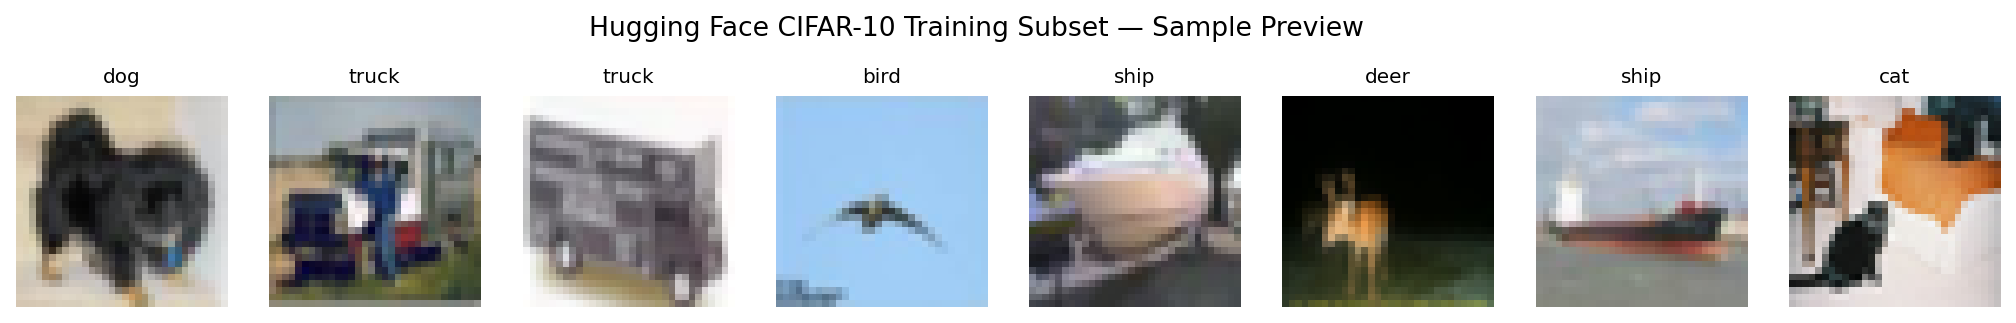

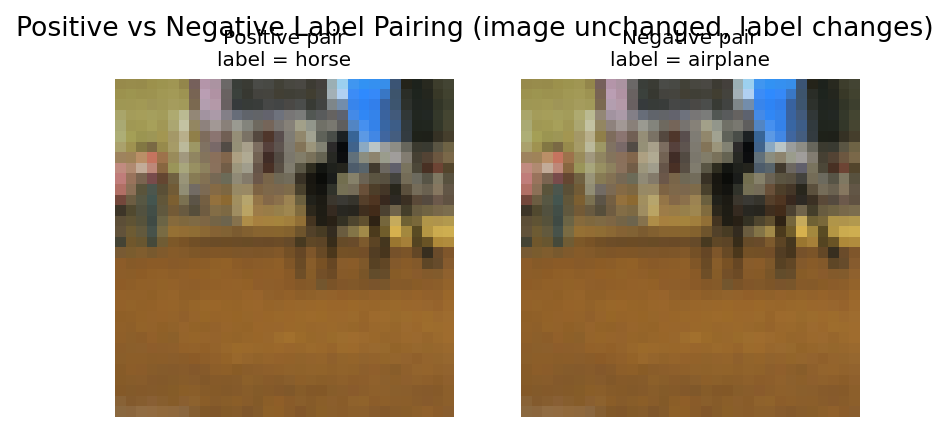

In [11]:
# -----------------------------------------------------------------------------
# 10. Visualization: CIFAR-10 sample preview
# -----------------------------------------------------------------------------
mean_tensor = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
std_tensor = torch.tensor(CIFAR_STD).view(3, 1, 1)


def denormalize(img_tensor: torch.Tensor) -> np.ndarray:
    img = img_tensor.detach().cpu() * std_tensor + mean_tensor
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img


preview_indices = torch.randperm(sample_images.size(0), generator=torch.Generator().manual_seed(SEED))[:8]
fig, axes = plt.subplots(1, 8, figsize=(16, 2.4))
fig.suptitle("Hugging Face CIFAR-10 Training Subset — Sample Preview", color="black")
for ax, idx in zip(axes, preview_indices.tolist()):
    img_np = denormalize(sample_images[idx])
    ax.imshow(img_np)
    ax.set_title(CLASS_NAMES[sample_labels[idx].item()], color="black", fontsize=9)
    ax.axis("off")
show_figure_inline(fig)

# Positive vs negative pairing illustration
demo_idx = 0
true_label = sample_labels[demo_idx].item()
neg_label = sample_neg_labels[demo_idx].item()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
fig.suptitle("Positive vs Negative Label Pairing (image unchanged, label changes)", color="black")
img_np = denormalize(sample_images[demo_idx])
axes[0].imshow(img_np)
axes[0].set_title(f"Positive pair\nlabel = {CLASS_NAMES[true_label]}", color="black", fontsize=9)
axes[0].axis("off")
axes[1].imshow(img_np)
axes[1].set_title(f"Negative pair\nlabel = {CLASS_NAMES[neg_label]}", color="black", fontsize=9)
axes[1].axis("off")
show_figure_inline(fig)

In [12]:
# -----------------------------------------------------------------------------
# 11. Forward-Forward Layer
# -----------------------------------------------------------------------------
class ForwardForwardLayer(nn.Module):
    """
    A single Forward-Forward layer.

    Trains itself using a LOCAL goodness objective (no global loss, no
    backpropagation through other layers). Only this layer's own parameters
    are updated by its own optimizer.
    """

    def __init__(
        self,
        in_features: int,
        out_features: int,
        threshold: float = 2.0,
        lr: float = 0.03,
        weight_decay: float = 1e-4,
        grad_clip_norm: float = 1.0,
        epsilon: float = 1e-6,
    ):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.threshold = threshold
        self.grad_clip_norm = grad_clip_norm
        self.epsilon = epsilon
        self.optimizer = torch.optim.Adam(
            self.linear.parameters(), lr=lr, weight_decay=weight_decay
        )

    def normalize(self, x: torch.Tensor) -> torch.Tensor:
        """L2-normalize each row (paper-style length normalization, NOT LayerNorm)."""
        norm = x.norm(p=2, dim=1, keepdim=True)
        return x / (norm + self.epsilon)

    def forward_raw(self, x: torch.Tensor) -> torch.Tensor:
        """hidden = ReLU(linear(normalized_input))."""
        x_norm = self.normalize(x)
        return F.relu(self.linear(x_norm))

    def goodness(self, hidden: torch.Tensor) -> torch.Tensor:
        """Goodness = mean of squared pre-normalization activations, per sample."""
        return (hidden ** 2).mean(dim=1)

    def local_loss(
        self, positive_goodness: torch.Tensor, negative_goodness: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        positive_loss = F.softplus(self.threshold - positive_goodness).mean()
        negative_loss = F.softplus(negative_goodness - self.threshold).mean()
        total_loss = positive_loss + negative_loss
        return positive_loss, negative_loss, total_loss

    def train_layer(
        self, positive_input: torch.Tensor, negative_input: torch.Tensor
    ) -> Dict[str, torch.Tensor]:
        """
        One local Forward-Forward training step for this layer only.
        Gradients are computed and applied ONLY to this layer's parameters.
        """
        self.train()
        hidden_pos = self.forward_raw(positive_input)
        hidden_neg = self.forward_raw(negative_input)

        pos_goodness = self.goodness(hidden_pos)
        neg_goodness = self.goodness(hidden_neg)

        pos_loss, neg_loss, total_loss = self.local_loss(pos_goodness, neg_goodness)

        if not torch.isfinite(total_loss):
            raise ValueError("Non-finite loss encountered in ForwardForwardLayer.train_layer().")

        self.optimizer.zero_grad()
        total_loss.backward()  # local backprop WITHIN this single layer only
        torch.nn.utils.clip_grad_norm_(self.linear.parameters(), self.grad_clip_norm)
        self.optimizer.step()

        with torch.no_grad():
            out_pos = self.normalize(hidden_pos.detach())
            out_neg = self.normalize(hidden_neg.detach())

        return {
            "positive_loss": pos_loss.detach(),
            "negative_loss": neg_loss.detach(),
            "total_loss": total_loss.detach(),
            "positive_goodness": pos_goodness.detach().mean(),
            "negative_goodness": neg_goodness.detach().mean(),
            "margin": (pos_goodness.detach().mean() - neg_goodness.detach().mean()),
            "output_positive": out_pos,   # detached, normalized -> next layer
            "output_negative": out_neg,   # detached, normalized -> next layer
        }

    @torch.inference_mode()
    def transform(self, x: torch.Tensor) -> torch.Tensor:
        """Inference-only pass: raw forward + detached normalized output + goodness."""
        hidden = self.forward_raw(x)
        goodness = self.goodness(hidden)
        normalized_out = self.normalize(hidden)
        return normalized_out, goodness

In [13]:
# -----------------------------------------------------------------------------
# 12. Network: stack of Forward-Forward layers
# -----------------------------------------------------------------------------
# NOTE: The paper's CIFAR-10 experiment used topographic hidden maps with
# local (non-weight-shared) receptive fields and ~3072 units per layer. Here
# we use smaller fully-connected layers purely to keep the educational Colab
# experiment fast, while preserving the core FF learning rule.
HIDDEN_DIMS = [512, 512, 256]
GOODNESS_THRESHOLD = 2.0
LAYER_LR = 0.03
LAYER_WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0

layer_dims = [COMBINED_INPUT_DIM] + HIDDEN_DIMS
ff_layers: List[ForwardForwardLayer] = []
for i in range(len(HIDDEN_DIMS)):
    layer = ForwardForwardLayer(
        in_features=layer_dims[i],
        out_features=layer_dims[i + 1],
        threshold=GOODNESS_THRESHOLD,
        lr=LAYER_LR,
        weight_decay=LAYER_WEIGHT_DECAY,
        grad_clip_norm=GRAD_CLIP_NORM,
    ).to(DEVICE)
    ff_layers.append(layer)

print("\n--- Network architecture ---")
total_params = 0
for i, layer in enumerate(ff_layers, start=1):
    n_params = sum(p.numel() for p in layer.parameters())
    total_params += n_params
    print(f"Layer {i}: in={layer_dims[i-1]}, out={layer_dims[i]}, params={n_params}")
print(f"Total trainable parameters: {total_params}")


--- Network architecture ---
Layer 1: in=3082, out=512, params=1578496
Layer 2: in=512, out=512, params=262656
Layer 3: in=512, out=256, params=131328
Total trainable parameters: 1972480


In [14]:
# -----------------------------------------------------------------------------
# 13. Candidate-label vectorized evaluation
# -----------------------------------------------------------------------------
@torch.inference_mode()
def evaluate_candidates(
    images_flat: torch.Tensor,
    layers: List[ForwardForwardLayer],
    exclude_first_layer: bool = True,
) -> Dict[str, torch.Tensor]:
    """
    Vectorized candidate-label goodness evaluation.

    Every image is paired with all NUM_CLASSES candidate labels in a single
    batched tensor (no per-image Python loop).
    """
    batch_size = images_flat.size(0)

    # Repeat each image NUM_CLASSES times: [B * C, D]
    repeated_images = images_flat.repeat_interleave(NUM_CLASSES, dim=0)
    # Candidate labels 0..C-1 tiled for every image: [B * C]
    candidate_labels = torch.arange(NUM_CLASSES, device=images_flat.device).repeat(batch_size)

    candidate_input = embed_label(repeated_images, candidate_labels)

    per_layer_goodness = []
    x = candidate_input
    for i, layer in enumerate(layers):
        x, goodness = layer.transform(x)
        if exclude_first_layer and i == 0:
            continue
        per_layer_goodness.append(goodness)

    stacked_goodness = torch.stack(per_layer_goodness, dim=0)  # [num_used_layers, B*C]
    accumulated = stacked_goodness.sum(dim=0)  # [B*C]

    candidate_scores = accumulated.view(batch_size, NUM_CLASSES)
    probabilities = torch.softmax(candidate_scores, dim=1)
    predicted_labels = candidate_scores.argmax(dim=1)
    confidence = probabilities.gather(1, predicted_labels.unsqueeze(1)).squeeze(1)

    per_layer_goodness_reshaped = [
        g.view(batch_size, NUM_CLASSES) for g in per_layer_goodness
    ]

    return {
        "predicted_labels": predicted_labels,
        "candidate_scores": candidate_scores,
        "probabilities": probabilities,
        "confidence": confidence,
        "per_layer_goodness": per_layer_goodness_reshaped,
    }

In [15]:
# -----------------------------------------------------------------------------
# 14. Training loop
# -----------------------------------------------------------------------------
NUM_EPOCHS = 5
NUM_LAYERS = len(ff_layers)

history: Dict[str, list] = {
    "train_total_loss": [],
    "val_total_loss": [],
    "train_acc": [],
    "val_acc": [],
    "per_class_val_acc_by_epoch": [],  # list of lists, [epoch][class]
}
for i in range(NUM_LAYERS):
    for key in ["pos_loss", "neg_loss", "total_loss", "pos_goodness", "neg_goodness", "margin"]:
        history[f"layer{i+1}_train_{key}"] = []
        history[f"layer{i+1}_val_{key}"] = []


@torch.no_grad()
def evaluate_local_losses(loader: DataLoader) -> Dict[str, float]:
    """Compute per-layer validation-style local losses/goodness without updating weights."""
    running = {f"layer{i+1}_{k}": 0.0 for i in range(NUM_LAYERS)
               for k in ["pos_loss", "neg_loss", "total_loss", "pos_goodness", "neg_goodness", "margin"]}
    n_batches = 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        images_flat = images.view(images.size(0), -1)
        neg_labels = make_negative_labels(labels)

        pos_input = embed_label(images_flat, labels)
        neg_input = embed_label(images_flat, neg_labels)

        x_pos, x_neg = pos_input, neg_input
        for i, layer in enumerate(ff_layers):
            hidden_pos = layer.forward_raw(x_pos)
            hidden_neg = layer.forward_raw(x_neg)
            pos_g = layer.goodness(hidden_pos)
            neg_g = layer.goodness(hidden_neg)
            pos_l, neg_l, tot_l = layer.local_loss(pos_g, neg_g)

            running[f"layer{i+1}_pos_loss"] += pos_l.item()
            running[f"layer{i+1}_neg_loss"] += neg_l.item()
            running[f"layer{i+1}_total_loss"] += tot_l.item()
            running[f"layer{i+1}_pos_goodness"] += pos_g.mean().item()
            running[f"layer{i+1}_neg_goodness"] += neg_g.mean().item()
            running[f"layer{i+1}_margin"] += (pos_g.mean() - neg_g.mean()).item()

            x_pos = layer.normalize(hidden_pos)
            x_neg = layer.normalize(hidden_neg)
        n_batches += 1

    for k in running:
        running[k] /= max(n_batches, 1)
    return running


@torch.no_grad()
def compute_accuracy(loader: DataLoader) -> Tuple[float, np.ndarray, np.ndarray]:
    correct = 0
    total = 0
    all_true, all_pred = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        images_flat = images.view(images.size(0), -1)
        result = evaluate_candidates(images_flat, ff_layers, exclude_first_layer=True)
        preds = result["predicted_labels"]
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_true.append(labels.cpu().numpy())
        all_pred.append(preds.cpu().numpy())
    acc = correct / max(total, 1)
    return acc, np.concatenate(all_true), np.concatenate(all_pred)


def per_class_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> List[float]:
    accs = []
    for c in range(NUM_CLASSES):
        mask = y_true == c
        if mask.sum() == 0:
            accs.append(0.0)  # safe handling of zero-sample classes
        else:
            accs.append((y_pred[mask] == c).mean())
    return accs


print("\n--- Training (greedy local Forward-Forward) ---")
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_layer_stats = {f"layer{i+1}_{k}": [] for i in range(NUM_LAYERS)
                          for k in ["pos_loss", "neg_loss", "total_loss", "pos_goodness", "neg_goodness", "margin"]}
    epoch_total_loss = 0.0
    n_batches = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False)
    for images, labels in progress_bar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        images_flat = images.view(images.size(0), -1)
        neg_labels = make_negative_labels(labels)
        assert torch.all(neg_labels != labels), "Negative label leakage detected."

        pos_input = embed_label(images_flat, labels)
        neg_input = embed_label(images_flat, neg_labels)

        x_pos, x_neg = pos_input, neg_input
        batch_total_loss = 0.0
        for i, layer in enumerate(ff_layers):
            stats = layer.train_layer(x_pos, x_neg)
            batch_total_loss += stats["total_loss"].item()

            epoch_layer_stats[f"layer{i+1}_pos_loss"].append(stats["positive_loss"].item())
            epoch_layer_stats[f"layer{i+1}_neg_loss"].append(stats["negative_loss"].item())
            epoch_layer_stats[f"layer{i+1}_total_loss"].append(stats["total_loss"].item())
            epoch_layer_stats[f"layer{i+1}_pos_goodness"].append(stats["positive_goodness"].item())
            epoch_layer_stats[f"layer{i+1}_neg_goodness"].append(stats["negative_goodness"].item())
            epoch_layer_stats[f"layer{i+1}_margin"].append(stats["margin"].item())

            # detached, normalized activations feed the next layer (no backprop across layers)
            x_pos = stats["output_positive"]
            x_neg = stats["output_negative"]

        epoch_total_loss += batch_total_loss
        n_batches += 1
        progress_bar.set_postfix({"batch_ff_loss": f"{batch_total_loss:.3f}"})

    train_total_loss = epoch_total_loss / max(n_batches, 1)

    # Validation-style local losses (no weight updates)
    val_local = evaluate_local_losses(test_loader)
    val_total_loss = sum(val_local[f"layer{i+1}_total_loss"] for i in range(NUM_LAYERS))

    # Classification accuracy
    train_acc, _, _ = compute_accuracy(train_eval_loader)
    val_acc, y_true_epoch, y_pred_epoch = compute_accuracy(test_loader)
    per_class_acc_epoch = per_class_accuracy(y_true_epoch, y_pred_epoch)

    history["train_total_loss"].append(train_total_loss)
    history["val_total_loss"].append(val_total_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["per_class_val_acc_by_epoch"].append(per_class_acc_epoch)

    for i in range(NUM_LAYERS):
        for k in ["pos_loss", "neg_loss", "total_loss", "pos_goodness", "neg_goodness", "margin"]:
            history[f"layer{i+1}_train_{k}"].append(float(np.mean(epoch_layer_stats[f"layer{i+1}_{k}"])))
            history[f"layer{i+1}_val_{k}"].append(val_local[f"layer{i+1}_{k}"])

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"train_ff_loss={train_total_loss:.4f} | val_ff_loss={val_total_loss:.4f} | "
        f"train_acc={train_acc*100:.2f}% | val_acc={val_acc*100:.2f}%"
    )


--- Training (greedy local Forward-Forward) ---


Epoch 1/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/5 | train_ff_loss=4.7576 | val_ff_loss=4.3372 | train_acc=7.75% | val_acc=7.50%


Epoch 2/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2/5 | train_ff_loss=4.2156 | val_ff_loss=4.1693 | train_acc=5.55% | val_acc=4.75%


...

Epoch 3/5 | train_ff_loss=4.1650 | val_ff_loss=4.1608 | train_acc=9.30% | val_acc=9.75%


Epoch 4/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 4/5 | train_ff_loss=4.1607 | val_ff_loss=4.1601 | train_acc=10.20% | val_acc=8.00%


Epoch 5/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 5/5 | train_ff_loss=4.1605 | val_ff_loss=4.1609 | train_acc=10.15% | val_acc=10.25%


In [16]:
# -----------------------------------------------------------------------------
# 15. Final evaluation
# -----------------------------------------------------------------------------
print("\n--- Final evaluation ---")
final_val_acc, y_true, y_pred = compute_accuracy(test_loader)

all_confidences = []
all_correct_mask = []
sample_predictions = []

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        images_flat = images.view(images.size(0), -1)
        result = evaluate_candidates(images_flat, ff_layers, exclude_first_layer=True)
        preds = result["predicted_labels"]
        conf = result["confidence"]
        correct_mask = (preds == labels)

        all_confidences.append(conf.cpu().numpy())
        all_correct_mask.append(correct_mask.cpu().numpy())

        if len(sample_predictions) < 8:
            for b in range(images.size(0)):
                if len(sample_predictions) >= 8:
                    break
                sample_predictions.append({
                    "image": images[b].cpu(),
                    "true": labels[b].item(),
                    "pred": preds[b].item(),
                    "confidence": conf[b].item(),
                })

all_confidences = np.concatenate(all_confidences)
all_correct_mask = np.concatenate(all_correct_mask)

correct_confidences = all_confidences[all_correct_mask]
incorrect_confidences = all_confidences[~all_correct_mask]

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
with np.errstate(invalid="ignore", divide="ignore"):
    cm_normalized = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

final_per_class_acc = per_class_accuracy(y_true, y_pred)

best_epoch_idx = int(np.argmax(history["val_acc"]))
best_val_acc = history["val_acc"][best_epoch_idx]

print(f"Final validation accuracy: {final_val_acc*100:.2f}%")
print(f"Best validation accuracy: {best_val_acc*100:.2f}% (epoch {best_epoch_idx + 1})")


--- Final evaluation ---
Final validation accuracy: 10.25%
Best validation accuracy: 10.25% (epoch 5)


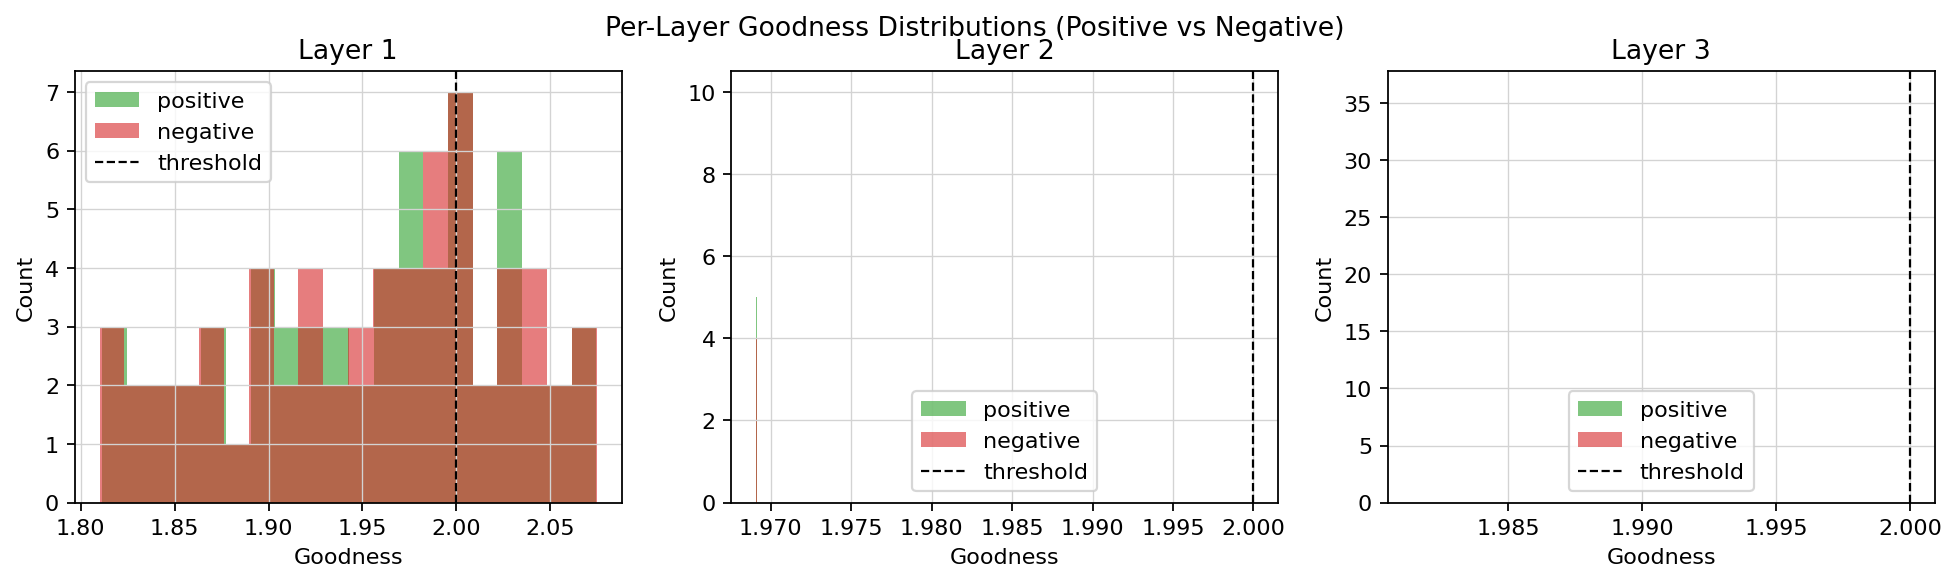

In [17]:
# -----------------------------------------------------------------------------
# 16. Educational visualization: per-layer goodness distributions
# -----------------------------------------------------------------------------
with torch.inference_mode():
    demo_images, demo_labels = next(iter(test_loader))
    demo_images = demo_images.to(DEVICE)
    demo_labels = demo_labels.to(DEVICE)
    demo_flat = demo_images.view(demo_images.size(0), -1)
    demo_neg_labels = make_negative_labels(demo_labels)

    x_pos = embed_label(demo_flat, demo_labels)
    x_neg = embed_label(demo_flat, demo_neg_labels)

    pos_goodness_per_layer, neg_goodness_per_layer = [], []
    for layer in ff_layers:
        x_pos, g_pos = layer.transform(x_pos)
        x_neg, g_neg = layer.transform(x_neg)
        pos_goodness_per_layer.append(g_pos.cpu().numpy())
        neg_goodness_per_layer.append(g_neg.cpu().numpy())

fig, axes = plt.subplots(1, NUM_LAYERS, figsize=(5 * NUM_LAYERS, 3.5))
if NUM_LAYERS == 1:
    axes = [axes]
fig.suptitle("Per-Layer Goodness Distributions (Positive vs Negative)", color="black")
for i, ax in enumerate(axes):
    ax.hist(pos_goodness_per_layer[i], bins=20, alpha=0.6, label="positive", color="#2ca02c")
    ax.hist(neg_goodness_per_layer[i], bins=20, alpha=0.6, label="negative", color="#d62728")
    ax.axvline(GOODNESS_THRESHOLD, color="black", linestyle="--", linewidth=1, label="threshold")
    ax.set_title(f"Layer {i+1}", color="black")
    ax.set_xlabel("Goodness")
    ax.set_ylabel("Count")
    ax.legend()
    apply_white_theme(ax, grid=True)
show_figure_inline(fig)

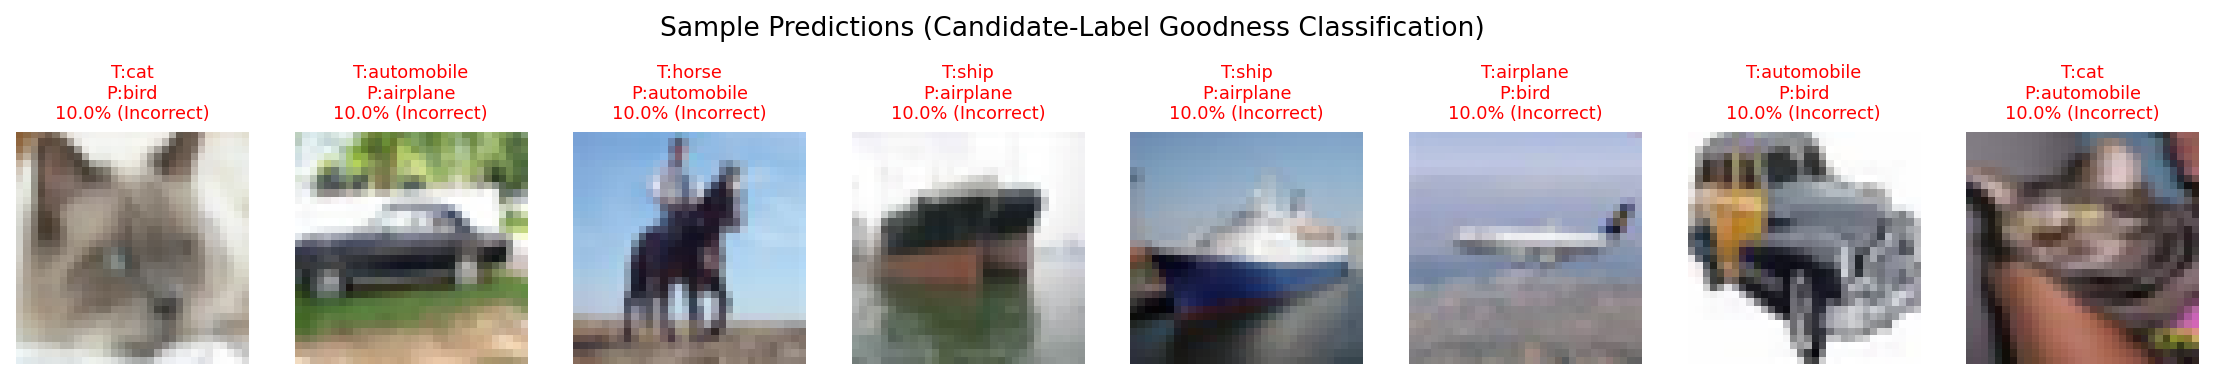

In [18]:
# -----------------------------------------------------------------------------
# 17. Educational visualization: sample predictions
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, len(sample_predictions), figsize=(2.2 * len(sample_predictions), 3))
fig.suptitle("Sample Predictions (Candidate-Label Goodness Classification)", color="black")
for ax, sample in zip(axes, sample_predictions):
    img_np = denormalize(sample["image"])
    ax.imshow(img_np)
    status = "Correct" if sample["true"] == sample["pred"] else "Incorrect"
    color = "green" if status == "Correct" else "red"
    ax.set_title(
        f"T:{CLASS_NAMES[sample['true']]}\nP:{CLASS_NAMES[sample['pred']]}\n"
        f"{sample['confidence']*100:.1f}% ({status})",
        color=color, fontsize=8,
    )
    ax.axis("off")
show_figure_inline(fig)

/tmp/ipykernel_7597/3155782172.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")


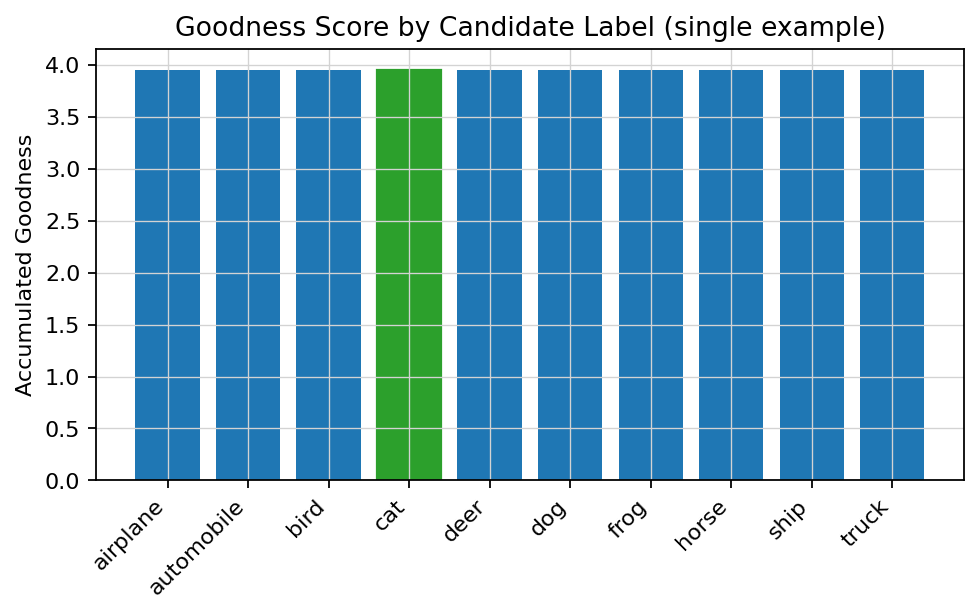

In [19]:
# -----------------------------------------------------------------------------
# 18. Optional: goodness-by-candidate-label plot for one selected image
# -----------------------------------------------------------------------------
with torch.inference_mode():
    one_image = demo_images[0:1]
    one_image_flat = one_image.view(1, -1)
    one_result = evaluate_candidates(one_image_flat, ff_layers, exclude_first_layer=True)
    one_scores = one_result["candidate_scores"].squeeze(0).cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(CLASS_NAMES, one_scores, color="#1f77b4")
true_idx = demo_labels[0].item()
bars[true_idx].set_color("#2ca02c")
ax.set_title("Goodness Score by Candidate Label (single example)", color="black")
ax.set_ylabel("Accumulated Goodness")
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
apply_white_theme(ax, grid=True)
show_figure_inline(fig)

/tmp/ipykernel_7597/3768864677.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_e.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")


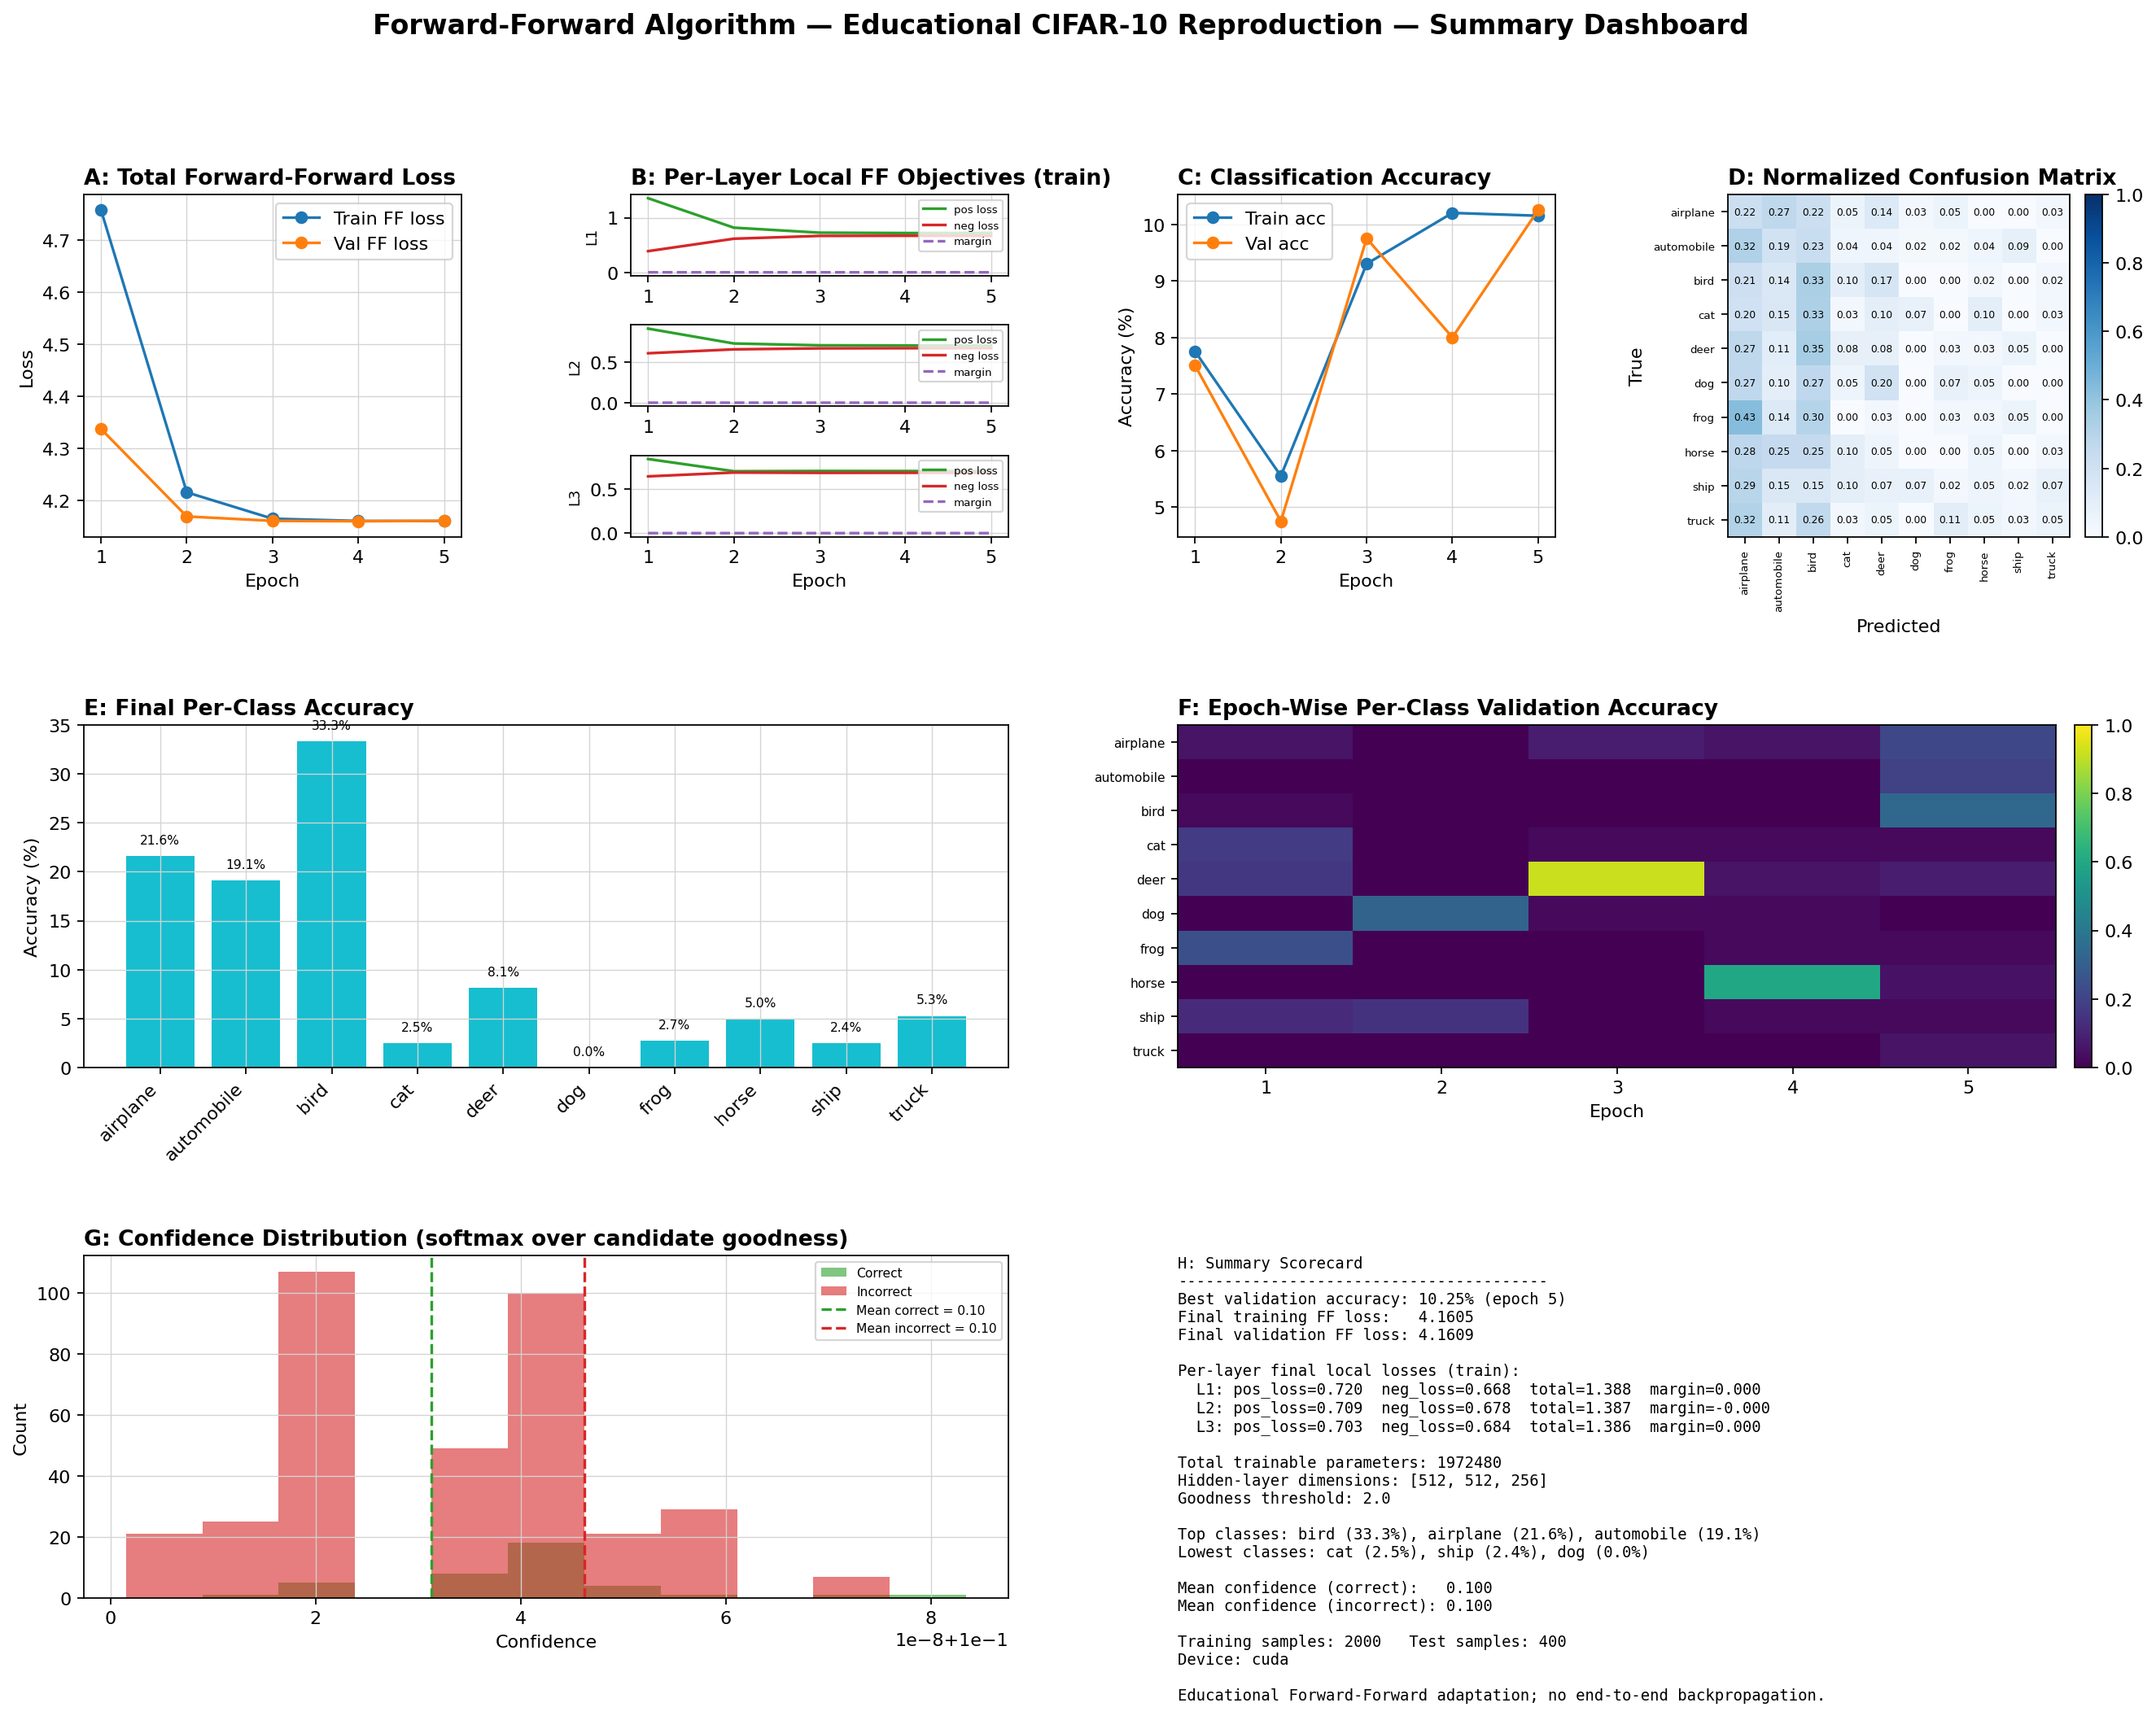

In [20]:
# =============================================================================
# 19. FINAL MULTI-PANEL SUMMARY DASHBOARD (must be the last visualization)
# =============================================================================
fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.45)

epochs_range = list(range(1, NUM_EPOCHS + 1))

# --- Panel A: Total Loss Curves ---
ax_a = fig.add_subplot(gs[0, 0])
ax_a.plot(epochs_range, history["train_total_loss"], marker="o", label="Train FF loss", color="#1f77b4")
ax_a.plot(epochs_range, history["val_total_loss"], marker="o", label="Val FF loss", color="#ff7f0e")
ax_a.set_title("A: Total Forward-Forward Loss", color="black", loc="left", fontweight="bold")
ax_a.set_xlabel("Epoch")
ax_a.set_ylabel("Loss")
ax_a.legend()
apply_white_theme(ax_a, grid=True)

# --- Panel B: Local Forward-Forward Objectives (nested sub-panels per layer) ---
gs_b = gs[0, 1].subgridspec(NUM_LAYERS, 1, hspace=0.6)
for i in range(NUM_LAYERS):
    ax_b = fig.add_subplot(gs_b[i, 0])
    ax_b.plot(epochs_range, history[f"layer{i+1}_train_pos_loss"], label="pos loss", color="#2ca02c")
    ax_b.plot(epochs_range, history[f"layer{i+1}_train_neg_loss"], label="neg loss", color="#d62728")
    ax_b.plot(epochs_range, history[f"layer{i+1}_train_margin"], label="margin", color="#9467bd", linestyle="--")
    if i == 0:
        ax_b.set_title("B: Per-Layer Local FF Objectives (train)", color="black", loc="left", fontweight="bold")
    ax_b.set_ylabel(f"L{i+1}", fontsize=8)
    if i == NUM_LAYERS - 1:
        ax_b.set_xlabel("Epoch")
    ax_b.legend(fontsize=6, loc="upper right")
    apply_white_theme(ax_b, grid=True)

# --- Panel C: Accuracy Curves ---
ax_c = fig.add_subplot(gs[0, 2])
ax_c.plot(epochs_range, [a * 100 for a in history["train_acc"]], marker="o", label="Train acc", color="#1f77b4")
ax_c.plot(epochs_range, [a * 100 for a in history["val_acc"]], marker="o", label="Val acc", color="#ff7f0e")
ax_c.set_title("C: Classification Accuracy", color="black", loc="left", fontweight="bold")
ax_c.set_xlabel("Epoch")
ax_c.set_ylabel("Accuracy (%)")
ax_c.legend()
apply_white_theme(ax_c, grid=True)

# --- Panel D: Normalized Confusion Matrix ---
ax_d = fig.add_subplot(gs[0, 3])
im_d = ax_d.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
ax_d.set_title("D: Normalized Confusion Matrix", color="black", loc="left", fontweight="bold")
ax_d.set_xticks(range(NUM_CLASSES))
ax_d.set_yticks(range(NUM_CLASSES))
ax_d.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
ax_d.set_yticklabels(CLASS_NAMES, fontsize=6)
ax_d.set_xlabel("Predicted")
ax_d.set_ylabel("True")
for r in range(NUM_CLASSES):
    for c in range(NUM_CLASSES):
        val = cm_normalized[r, c]
        text_color = "white" if val > 0.5 else "black"
        ax_d.text(c, r, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=5.5)
cbar_d = fig.colorbar(im_d, ax=ax_d, fraction=0.046, pad=0.04)
cbar_d.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar_d.ax.get_yticklabels(), color="black")
apply_white_theme(ax_d, grid=False)

# --- Panel E: Per-Class Accuracy ---
ax_e = fig.add_subplot(gs[1, 0:2])
bars_e = ax_e.bar(CLASS_NAMES, [a * 100 for a in final_per_class_acc], color="#17becf")
ax_e.set_title("E: Final Per-Class Accuracy", color="black", loc="left", fontweight="bold")
ax_e.set_ylabel("Accuracy (%)")
ax_e.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
for bar, val in zip(bars_e, final_per_class_acc):
    ax_e.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
               f"{val*100:.1f}%", ha="center", va="bottom", color="black", fontsize=7)
apply_white_theme(ax_e, grid=True)

# --- Panel F: Epoch-Wise Per-Class Accuracy Heatmap ---
ax_f = fig.add_subplot(gs[1, 2:4])
heatmap_data = np.array(history["per_class_val_acc_by_epoch"]).T  # [classes, epochs]
im_f = ax_f.imshow(heatmap_data, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax_f.set_title("F: Epoch-Wise Per-Class Validation Accuracy", color="black", loc="left", fontweight="bold")
ax_f.set_xticks(range(NUM_EPOCHS))
ax_f.set_xticklabels(epochs_range)
ax_f.set_yticks(range(NUM_CLASSES))
ax_f.set_yticklabels(CLASS_NAMES, fontsize=7)
ax_f.set_xlabel("Epoch")
cbar_f = fig.colorbar(im_f, ax=ax_f, fraction=0.03, pad=0.02)
cbar_f.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar_f.ax.get_yticklabels(), color="black")
apply_white_theme(ax_f, grid=False)

# --- Panel G: Confidence Distribution ---
ax_g = fig.add_subplot(gs[2, 0:2])
ax_g.hist(correct_confidences, bins=20, alpha=0.6, label="Correct", color="#2ca02c")
ax_g.hist(incorrect_confidences, bins=20, alpha=0.6, label="Incorrect", color="#d62728")
if correct_confidences.size > 0:
    ax_g.axvline(correct_confidences.mean(), color="#2ca02c", linestyle="--",
                 label=f"Mean correct = {correct_confidences.mean():.2f}")
if incorrect_confidences.size > 0:
    ax_g.axvline(incorrect_confidences.mean(), color="#d62728", linestyle="--",
                 label=f"Mean incorrect = {incorrect_confidences.mean():.2f}")
ax_g.set_title("G: Confidence Distribution (softmax over candidate goodness)", color="black", loc="left", fontweight="bold")
ax_g.set_xlabel("Confidence")
ax_g.set_ylabel("Count")
ax_g.legend(fontsize=7)
apply_white_theme(ax_g, grid=True)

# --- Panel H: Text Summary Scorecard ---
ax_h = fig.add_subplot(gs[2, 2:4])
ax_h.axis("off")
apply_white_theme(ax_h, grid=False)

sorted_classes = sorted(zip(CLASS_NAMES, final_per_class_acc), key=lambda t: t[1], reverse=True)
top_classes = ", ".join(f"{name} ({acc*100:.1f}%)" for name, acc in sorted_classes[:3])
bottom_classes = ", ".join(f"{name} ({acc*100:.1f}%)" for name, acc in sorted_classes[-3:])

layer_lines = []
for i in range(NUM_LAYERS):
    layer_lines.append(
        f"  L{i+1}: pos_loss={history[f'layer{i+1}_train_pos_loss'][-1]:.3f}  "
        f"neg_loss={history[f'layer{i+1}_train_neg_loss'][-1]:.3f}  "
        f"total={history[f'layer{i+1}_train_total_loss'][-1]:.3f}  "
        f"margin={history[f'layer{i+1}_train_margin'][-1]:.3f}"
    )

summary_text = (
    "H: Summary Scorecard\n"
    "----------------------------------------\n"
    f"Best validation accuracy: {best_val_acc*100:.2f}% (epoch {best_epoch_idx + 1})\n"
    f"Final training FF loss:   {history['train_total_loss'][-1]:.4f}\n"
    f"Final validation FF loss: {history['val_total_loss'][-1]:.4f}\n\n"
    "Per-layer final local losses (train):\n" + "\n".join(layer_lines) + "\n\n"
    f"Total trainable parameters: {total_params}\n"
    f"Hidden-layer dimensions: {HIDDEN_DIMS}\n"
    f"Goodness threshold: {GOODNESS_THRESHOLD}\n\n"
    f"Top classes: {top_classes}\n"
    f"Lowest classes: {bottom_classes}\n\n"
    f"Mean confidence (correct):   {correct_confidences.mean() if correct_confidences.size else float('nan'):.3f}\n"
    f"Mean confidence (incorrect): {incorrect_confidences.mean() if incorrect_confidences.size else float('nan'):.3f}\n\n"
    f"Training samples: {len(train_subset)}   Test samples: {len(test_subset)}\n"
    f"Device: {DEVICE}\n\n"
    "Educational Forward-Forward adaptation; no end-to-end backpropagation."
)
ax_h.text(0.0, 1.0, summary_text, transform=ax_h.transAxes, fontsize=8.5,
          va="top", ha="left", color="black", family="monospace")

fig.suptitle(
    "Forward-Forward Algorithm — Educational CIFAR-10 Reproduction — Summary Dashboard",
    color="black", fontsize=15, fontweight="bold",
)

# Final display — must be the last action in the entire code.
show_figure_inline(fig)

## Analysis of Forward-Forward CIFAR-10 Educational Reproduction — Summary Dashboard

---

### Result 1: Training and Validation Loss Curves (Panels A & B)

#### Overview
Panel A tracks the total Forward-Forward (FF) loss across five epochs for both training and validation splits. Panel B decomposes this into per-layer positive loss, negative loss, and goodness margin for each of the three hidden layers, isolating the local objective each layer is independently optimizing.

#### Key Findings
- Total loss drops sharply between epoch 1 (~4.75 train / ~4.34 val) and epoch 2 (~4.22 / ~4.17), then plateaus near 4.16 for the remaining three epochs.
- All three layers show positive and negative losses converging to nearly identical values (≈0.68–0.72) by epoch 2, and the goodness margin (mean positive goodness − mean negative goodness) flattens to approximately zero across all layers for the remainder of training.

#### Discussion
The rapid early drop followed by a hard plateau indicates the network quickly reaches a local equilibrium in which each layer can no longer distinguish positive from negative goodness. A near-zero margin means the softplus-based local loss has stopped providing a meaningful gradient signal — positive and negative goodness values are statistically indistinguishable. This is consistent with **representational collapse**: the layers converge to a trivial solution that minimizes the local loss without learning discriminative features, rather than the intended separation of goodness above/below threshold for real versus corrupted label pairings. The absence of any loss reduction after epoch 2 (both train and validation move together) also indicates no overfitting is occurring — the model simply stops learning altogether.

#### Limitations
Only five epochs and a 2,000-sample training subset were used, which is far below the scale (tens of thousands of examples, dozens of epochs) that Hinton's original experiments required for FF to separate positive/negative goodness reliably. The flat margin could reflect insufficient training rather than a fundamental algorithmic failure, and the fixed goodness threshold (2.0) and learning rate were not tuned per layer, which may have contributed to premature convergence to a degenerate solution.

---

### Result 2: Classification Accuracy and Confusion Matrix (Panels C & D)

#### Overview
Panel C shows candidate-label classification accuracy (via accumulated goodness across layers 2–3) for train and validation sets across epochs. Panel D presents the row-normalized confusion matrix for the final model on the test subset.

#### Key Findings
- Accuracy oscillates between roughly 5% and 10% across epochs, never exceeding the 10-class chance baseline of 10% by a meaningful margin, and train/validation curves move together with no consistent upward trend.
- The confusion matrix shows a strong prediction bias toward "bird" (columns), with true classes such as *frog* (0.43), *deer* (0.35), and *cat* (0.33) most frequently misclassified as *bird*, while several classes (e.g., *dog*, *frog*, *ship*) receive almost no correct predictions.

#### Discussion
The classifier's accuracy hovering at or below chance level, combined with a single dominant predicted class across nearly all rows of the confusion matrix, confirms that the network has not learned label-discriminative goodness signals. Rather than distributing predictions according to visual similarity between classes (a pattern expected even from a partially-trained classifier), the model has collapsed onto a narrow set of "attractor" labels — a common failure mode when per-layer contrastive objectives saturate early (as seen in Panels A/B) and candidate goodness scores become nearly uniform across labels, making the argmax decision effectively arbitrary and sensitive to minor numerical asymmetries between label embeddings.

#### Discussion (continued): relation to paper's claims
This result does **not** support the original paper's core empirical claim that FF can approach backpropagation-level accuracy (paper reports ~0.6–1.4% test error on MNIST and competitive CIFAR-10 performance). The gap is attributable to the drastically reduced scale of this educational adaptation (small fully-connected layers, 2,000 training images, 5 epochs) rather than a refutation of the FF algorithm itself.

#### Limitations
The 400-sample test set is small, so per-class accuracy estimates (especially for rare correct predictions) carry high variance. The confusion pattern may partly reflect class-imbalanced difficulty in the random subset rather than a systematic algorithmic bias toward "bird." No comparison backpropagation baseline was run under identical constraints, limiting causal attribution of poor performance specifically to the FF mechanism.

---

### Result 3: Per-Class and Epoch-Wise Accuracy (Panels E & F)

#### Overview
Panel E reports final per-class validation accuracy as a bar chart; Panel F shows how per-class accuracy evolves across epochs as a heatmap.

#### Key Findings
- Only *bird* (33.3%), *airplane* (21.6%), and *automobile* (19.1%) achieve accuracy meaningfully above chance; *dog* achieves 0% accuracy, and several other classes remain below 5%.
- The epoch-wise heatmap shows sparse, inconsistent bright cells (e.g., *deer* briefly peaking near epoch 3, *horse* near epoch 4) rather than a stable, monotonically improving diagonal pattern.

#### Discussion
The concentration of correct predictions in just two or three classes, combined with volatile and non-persistent per-class spikes across epochs, indicates the network has not developed stable, generalizable class-specific representations. Instead, transient correct predictions for classes like *deer* or *horse* likely reflect incidental goodness fluctuations near the decision threshold rather than learned discriminative structure. This pattern is consistent with the collapsed margins observed in Panel B — without a persistent positive/negative goodness gap, classification outcomes are effectively noise-dominated.

#### Limitations
With only ~40 test examples per class (400 samples / 10 classes), single-epoch per-class accuracy is a noisy estimator, and apparent "peaks" for particular classes at particular epochs may not be statistically meaningful.

---

### Result 4: Confidence Distribution (Panel G)

#### Overview
Panel G shows the distribution of softmax-derived confidence scores (computed from candidate-label goodness) separately for correctly and incorrectly classified test examples.

#### Key Findings
- Both correct and incorrect predictions cluster tightly around a confidence value of approximately 0.10 (mean correct ≈ 0.10, mean incorrect ≈ 0.10), with no visible separation between the two distributions.

#### Discussion
A mean confidence of ~0.10 corresponds exactly to the uniform-distribution expectation for 10 classes (1/10), confirming that the candidate goodness scores across labels are nearly indistinguishable for a given image. This is the clearest quantitative evidence of collapse in the network's discriminative signal: the softmax is essentially operating on near-flat logits, so confidence conveys no information about prediction reliability, and correctness is effectively decoupled from confidence. This directly corroborates the near-zero goodness margins reported in Panel B.

#### Limitations
Because confidence and correctness are both degenerate here, this panel cannot be used to assess calibration quality in any meaningful sense; a properly trained FF model would be expected to show a clear rightward shift and separation between correct and incorrect confidence distributions, which is absent in this run.

---

### Result 5: Summary Scorecard (Panel H)

#### Overview
Panel H aggregates final quantitative outcomes: best validation accuracy, final losses, per-layer statistics, parameter count, and dataset/hardware configuration.

#### Key Findings
- Best validation accuracy reached only 10.25% (epoch 5), effectively at chance level for a 10-class problem.
- All three layers report positive/negative loss values within ~0.02–0.05 of each other and margins of approximately 0.000, with ~1.97M total trainable parameters trained on only 2,000 images for 5 epochs.

#### Discussion
Collectively, the scorecard confirms that this particular training run did not achieve meaningful discriminative learning under the Forward-Forward objective. The near-zero margins across all three layers simultaneously (rather than just the final layer) suggest the collapse originates early in training and propagates forward, consistent with FF's greedy layer-wise design in which early-layer failure directly limits what later layers can learn from normalized inputs.

#### Discussion: Alignment with the original paper
These results illustrate a key practical limitation implicit in Hinton's paper: FF's effectiveness is sensitive to training scale, threshold tuning, and negative-data quality — factors the original paper controls carefully (larger networks, tens of epochs, thousands of training examples, and hand-tuned goodness thresholds). The educational reproduction, constrained to a small subset and few epochs, was not expected to replicate the paper's reported ~1.1–1.4% MNIST error or competitive CIFAR-10 performance, and the results should be interpreted as a demonstration of the FF mechanism's implementation rather than a validation of its reported empirical performance.

#### Limitations
Overall conclusions are constrained by: (1) an extremely limited data scale (2,000/400 samples vs. the tens of thousands used in the original study), (2) a fixed, likely suboptimal goodness threshold and learning rate applied uniformly across layers, (3) only five training epochs versus 60–500 in the original experiments, and (4) absence of a matched backpropagation control run for direct comparison under identical constraints. These factors substantially limit the generalizability of the collapse observed here to conclusions about the Forward-Forward algorithm's intrinsic capability.

# Related Work Table
## The Forward-Forward Algorithm: Some Preliminary Investigations (Hinton, 2022)

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Rumelhart, D. E., Hinton, G. E., & Williams, R. J. | 1986 | Learning representations by backpropagating errors | *Nature* | Introduces the backpropagation algorithm that FF is proposed as an alternative to, motivating the paper's critique of backpropagation's biological implausibility. |
| Lillicrap, T., Santoro, A., Marris, L., Akerman, C., & Hinton, G. E. | 2020 | Backpropagation and the brain | *Nature Reviews Neuroscience* | Surveys efforts to reconcile backpropagation with cortical learning; cited as evidence that backpropagation remains an implausible model of cortex despite considerable effort. |
| Richards, B. A., & Lillicrap, T. P. | 2019 | Dendritic solutions to the credit assignment problem | *Current Opinion in Neurobiology* | Represents biologically-motivated attempts to implement backprop-like credit assignment via dendrites, contrasted with FF's simpler, non-backpropagating approach. |
| Guerguiev, J., Lillicrap, T. P., & Richards, B. A. | 2017 | Towards deep learning with segregated dendrites | *eLife* | Cited alongside dendritic credit-assignment models as prior work attempting to make backpropagation biologically plausible. |
| Scellier, B., & Bengio, Y. | 2017 | Equilibrium propagation: Bridging the gap between energy-based models and backpropagation | *Frontiers in Computational Neuroscience* | Prior energy-based alternative to backpropagation; situates FF within the broader landscape of biologically plausible learning rules. |
| Lillicrap, T., Cownden, D., Tweed, D., & Akerman, C. | 2016 | Random synaptic feedback weights support error backpropagation for deep learning | *Nature Communications* | Demonstrates feedback-alignment as an approximation to backpropagation; discussed as a method that works on small tasks (e.g., MNIST) but scales poorly, motivating FF's alternative approach. |
| Hinton, G., & Sejnowski, T. | 1986 | Learning and relearning in Boltzmann machines | In *Parallel Distributed Processing*, Vol. 1 | Foundational precursor to FF; FF is explicitly described as combining Boltzmann Machine-style contrastive learning with a simpler, tractable local goodness function. |
| Gutmann, M., & Hyvärinen, A. | 2010 | Noise-contrastive estimation: A new estimation principle for unnormalized statistical models | *Proceedings of AISTATS* | Cited as a direct inspirational precedent for FF's contrastive positive/negative data framework. |
| Hinton, G. E. | 2002 | Training products of experts by minimizing contrastive divergence | *Neural Computation* | Introduces contrastive divergence, an efficiency improvement over full Boltzmann Machine sampling; discussed in relation to how FF further simplifies contrastive learning without equilibrium sampling. |
| Hinton, G., Osindero, S., Welling, M., & Teh, Y.-W. | 2006 | Unsupervised discovery of nonlinear structure using contrastive backpropagation | *Cognitive Science* | Example of extending Boltzmann-style contrastive learning to arbitrary energy functions via backpropagation; contrasted with FF's avoidance of backpropagation altogether. |
| Grathwohl, W., Wang, K.-C., Jacobsen, J.-H., Duvenaud, D., Norouzi, M., & Swersky, K. | 2019 | Your classifier is secretly an energy-based model and you should treat it like one | *arXiv preprint* | Cited as an effective application of energy-based contrastive learning with gradient-based negative sampling, discussed in relation to FF's negative data generation strategy. |
| Goodfellow, I., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley, D., Ozair, S., Courville, A., & Bengio, Y. | 2014 | Generative adversarial nets | *Advances in Neural Information Processing Systems (NeurIPS)* | FF is explicitly framed as a special case of a GAN in which each layer makes its own greedy discriminative decision, avoiding backpropagation and mode collapse. |
| Chen, T., Kornblith, S., Norouzi, M., & Hinton, G. | 2020 | A simple framework for contrastive learning of visual representations (SimCLR) | *Proceedings of ICML* | Representative self-supervised contrastive method compared to FF; paper discusses differences in how agreement/disagreement between representations is measured. |
| Chen, T., Kornblith, S., Swersky, K., Norouzi, M., & Hinton, G. | 2020 | Big self-supervised models are strong semi-supervised learners | *arXiv preprint* | Cited within the SimCLR-family discussion as related contrastive self-supervised learning work using two-crop comparison objectives. |
| He, K., Fan, H., Wu, Y., Xie, S., & Girshick, R. | 2020 | Momentum contrast for unsupervised visual representation learning (MoCo) | *Proceedings of CVPR* | Included among crop-comparison contrastive methods (SimCLR-family) that FF is positioned against methodologically. |
| Grill, J.-B., Strub, F., Altché, F., Tallec, C., Richemond, P. H., Buchatskaya, E., Doersch, C., Pires, B. A., Guo, Z. D., Azar, M. G., Piot, B., Kavukcuoglu, K., Munos, R., & Valko, M. | 2020 | Bootstrap your own latent: A new approach to self-supervised learning (BYOL) | *arXiv preprint* | Cited as part of the family of image-crop contrastive methods; FF is distinguished by its use of within-layer interference rather than cross-crop representation comparison. |
| Bachman, P., Hjelm, R. D., & Buchwalter, W. | 2019 | Learning representations by maximizing mutual information across views | *Advances in Neural Information Processing Systems (NeurIPS)* | Cited among crop/view-based contrastive learning approaches discussed as related but methodologically distinct from FF's local goodness mechanism. |
| Wu, Z., Xiong, Y., Yu, S. X., & Lin, D. | 2018 | Unsupervised feature learning via non-parametric instance discrimination | *Proceedings of CVPR* | Early instance-discrimination contrastive method cited as part of the lineage of self-supervised contrastive techniques that FF is compared against. |
| Löwe, S., O'Connor, P., & Veeling, B. | 2019 | Putting an end to end-to-end: Gradient-isolated learning of representations | *Advances in Neural Information Processing Systems (NeurIPS)* | Directly relevant prior work using spatially localized contrastive blocks without end-to-end gradient flow; cited as a precedent and future-work reference for FF's block-based scaling strategy. |
| Crick, F., & Mitchison, G. | 1983 | The function of dream sleep | *Nature* | Motivates the paper's discussion (Section 5) of whether FF's positive/negative phases could correspond biologically to wake/sleep cycles, connecting to REM-sleep theories of learning. |
| Kohan, A. A., Rietman, E. A., & Siegelmann, H. T. | 2018 | Error forward-propagation: Reusing feedforward connections to propagate errors in deep learning | *arXiv preprint* | Related method using label information as an additional input for supervised learning without full backpropagation; noted as methodologically similar to FF's supervised label-embedding approach. |
| Kohan, A. A., Rietman, E. A., & Siegelmann, H. T. | 2022 | Signal propagation: A framework for learning and inference in a forward pass | *arXiv preprint* | Closely related forward-pass-only learning framework; distinguished from FF in that FF does not require separating hidden representations of labels and images. |
| Nock, R., & Guillame-Bert, M. | 2022 | Generative trees: Adversarial and copycat | *arXiv preprint* | Cited as using an analogous "weight/representation sharing" trick between generative and discriminative components, paralleling FF's reuse of discriminative representations for generation. |

**Note:** This table includes works explicitly discussed in the paper's comparative/theoretical sections (Sections 1, 5, and 6) as directly related methods or motivating background, rather than all references in the bibliography (which also include dataset sources, regularization techniques, and general deep learning citations not framed as related work per se).